Sales Forecasting by relevent models line linear regression , arima , sarima etc.

Problems:-
- understand the patterns over time of slaes.

- futur prediction of sales for impove in sales next time.

- evaluation by accuracy , so that we can work accordingly

In [79]:
#libraries imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings("ignore")

In [80]:
#make plots look decent
plt.rcParams["figure.figsize"] = (12,5)
plt.rcParams["axes.grid"] = True
#load the dataset
df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [81]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


In [82]:
df.shape

(9800, 18)

In [83]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [84]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [86]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


thus this indicates there is null values in 'postal code' so we have to fix them  by the means or median values or delete the row if not needne in the dataset for prediction, so that the prediction should not show any wrong prediction.

In [87]:
df['Postal Code'] = df['Postal Code'].fillna(df['Postal Code'].median())  #fixed with median

In [88]:
df.isna().sum().sum()

np.int64(0)

In [89]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
9795,False
9796,False
9797,False
9798,False


In [90]:
#converting order dates and ship date to datetime format.
for col in ['Order Date', 'Ship Date']:
    df[col] = pd.to_datetime(df[col], dayfirst=True)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [91]:
#just for the understanding , we have created some columns as year,month, montha name, day and day_of week
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.month_name()
df['Day'] = df['Order Date'].dt.day
df['Day_of_Week'] = df['Order Date'].dt.dayofweek

In [92]:
df[['Order Date', 'Year', 'Month', 'Month_Name', 'Day', 'Day_of_Week']].head()

,Order Date,Year,Month,Month_Name,Day,Day_of_Week
0,2017-11-08,2017,11,November,8,2
1,2017-11-08,2017,11,November,8,2
2,2017-06-12,2017,6,June,12,0
3,2016-10-11,2016,10,October,11,1
4,2016-10-11,2016,10,October,11,1


In [93]:
df = df.sort_values('Order Date')  # for understanding the trend pattern
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month_Name,Day,Day_of_Week
7980,7981,CA-2015-103800,2015-01-03,2015-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2015,1,January,3,5
741,742,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2015,1,January,4,6
740,741,CA-2015-112326,2015-01-04,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,2015,1,January,4,6


In [94]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

Order Date
2015-01-01    14205.707
2015-02-01     4519.892
2015-03-01    55205.797
2015-04-01    27906.855
2015-05-01    23644.303
Freq: MS, Name: Sales, dtype: float64


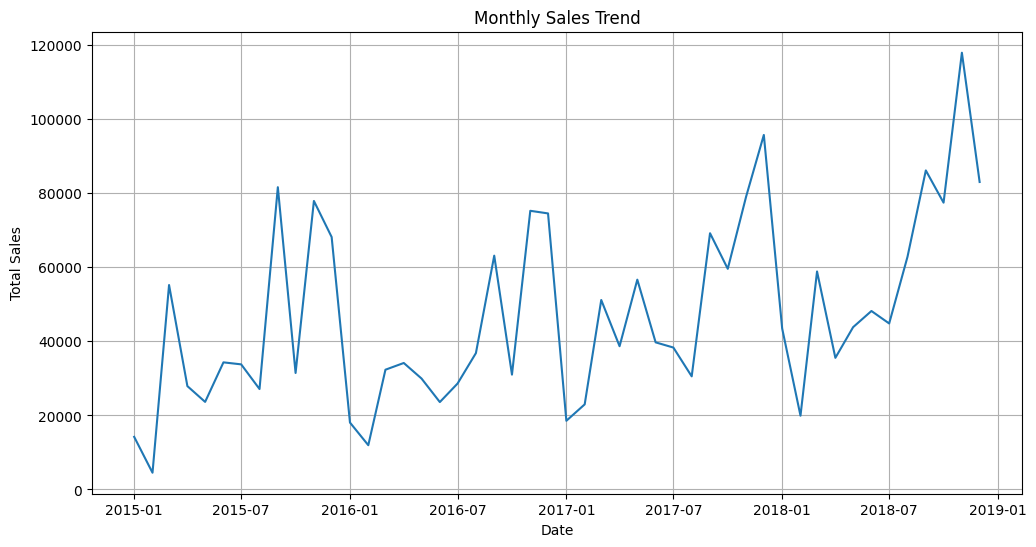

In [95]:
monthly_sales.index = monthly_sales.index.to_timestamp()

print(monthly_sales.head())

plt.figure(figsize=(12, 6))

plt.plot(monthly_sales)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.grid(True)
plt.show()

Interpritation :-

- This plot show that the trend by month is increasing upwards. as 2015-01 is around 17000 , but 2019-01 is around 82000 which clearly shows the trend is increasing .

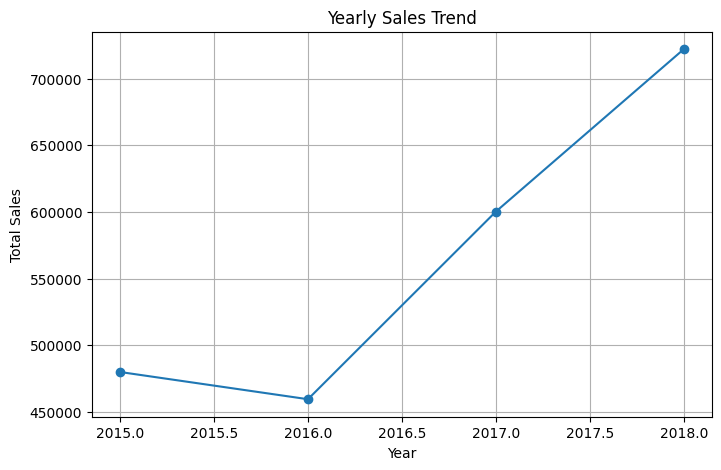

In [96]:
yearly_sales = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(8, 5))

plt.plot(
    yearly_sales.index,
    yearly_sales.values,
    marker='o'
)

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.grid(True)
plt.show()

- same as monthly , yearly also shows the trend is increase , as 2015- 2016 its lower but after 2016 ist have sharp high increse in sales .

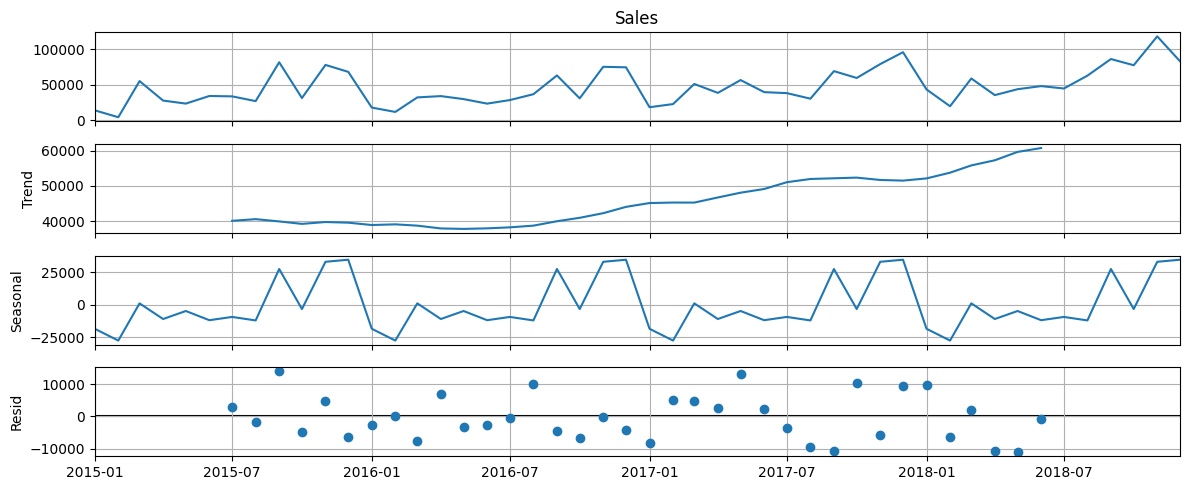

In [97]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_sales,
    model='additive',
    period=12
)

decomposition.plot()

plt.show()

interpretation:-

- trend is increasing of sales as clearly visual in plot, line plot shows that the increseing the sales about increse in years.

- seasonality as pictured has almost some pattern , starting has lower sales , then increses and then goes down , and repeat its patterns , over seasons.

- noise are spred all over the ranges  as its some are very high and some are low but from centre they can be calculated .

# Splitting Datasets

In [98]:
x = monthly_sales.iloc[:-12]

y = monthly_sales.iloc[-12:]

In [99]:
x.shape, x.shape

((36,), (36,))

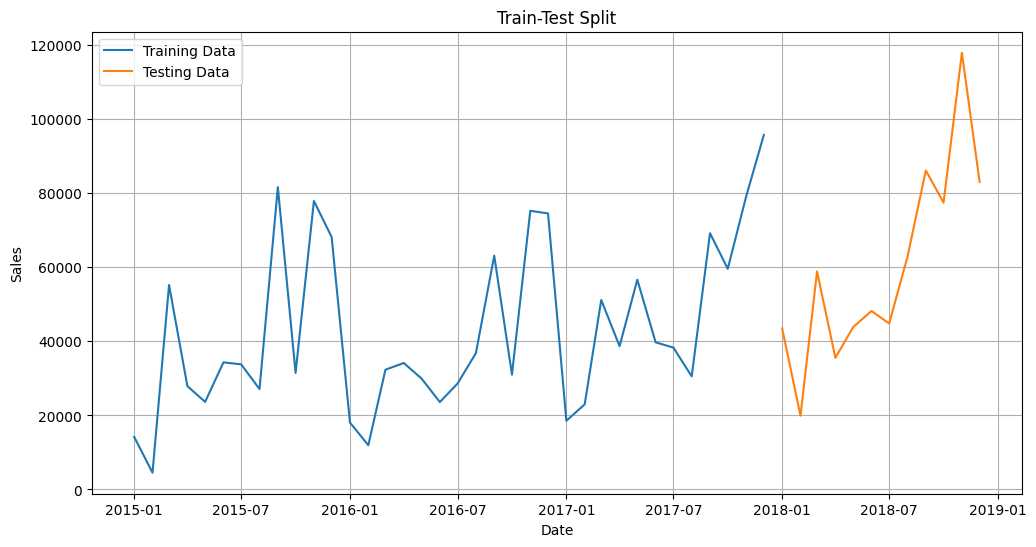

In [100]:
plt.figure(figsize=(12, 6))

plt.plot(x, label='Training Data')
plt.plot(y, label='Testing Data')

plt.title("Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

ARIMA model

In [101]:
#ARIMA model forecasting.
model_arima= ARIMA(x,order=(1, 1, 1))
model_fit = model_arima.fit()

In [102]:
y_pred_arima= model_fit.forecast(steps=len(y))
print(y_pred_arima)

2018-01-01    70808.434816
2018-02-01    67068.797168
2018-03-01    66507.846313
2018-04-01    66423.702904
2018-05-01    66411.081275
2018-06-01    66409.188013
2018-07-01    66408.904021
2018-08-01    66408.861422
2018-09-01    66408.855032
2018-10-01    66408.854074
2018-11-01    66408.853930
2018-12-01    66408.853908
Freq: MS, Name: predicted_mean, dtype: float64


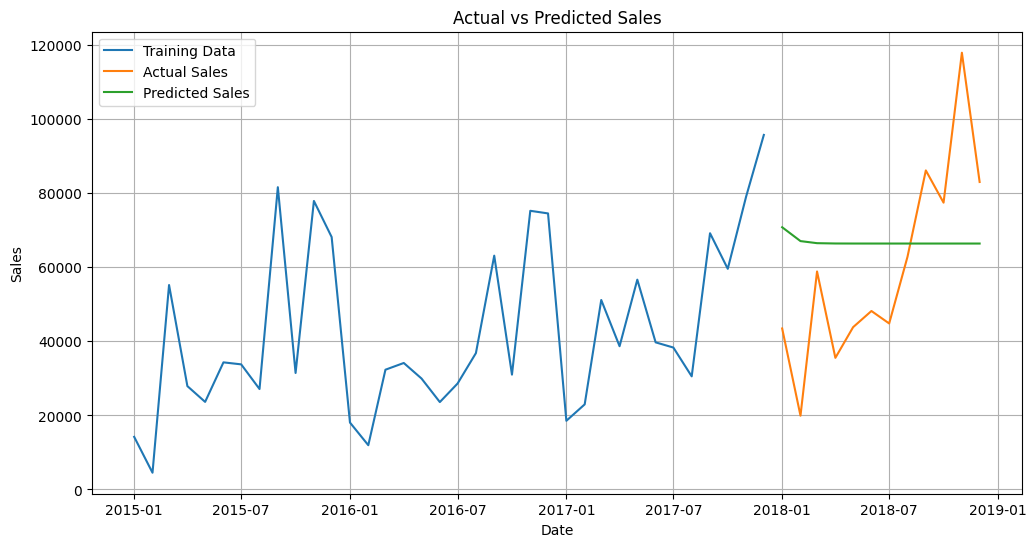

In [103]:
plt.figure(figsize=(12, 6))

plt.plot(x, label='Training Data')

plt.plot(y,label='Actual Sales')

plt.plot(y_pred_arima,label='Predicted Sales')

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

In [104]:
import sklearn.metrics as metrics
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

mae = mean_absolute_error(y,y_pred_arima)
rmse = np.sqrt(mean_squared_error(y,y_pred_arima))
r2 = r2_score(y,y_pred_arima)



print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))


MAE: 23158.21
RMSE: 26996.79
R² Score: -0.0941


SARIMA model

In [105]:
#stationarity test
adf_result = adfuller(monthly_sales)
print("ADf Statistics: %3f,p-value: %.3f" % (adf_result[0], adf_result[1]))

ADf Statistics: -4.416137,p-value: 0.000


as by the adf values , we can say that the data is stationary as its value is less then p-vlaue wich indicate the stationarity of data.

In [106]:

model_sarima = ARIMA(x, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),enforce_stationarity=False,
                       enforce_invertibility=False)
model_fit_2= model_sarima.fit()

print(model_fit_2.summary())

                                    SARIMAX Results                                     
Dep. Variable:                            Sales   No. Observations:                   36
Model:             ARIMA(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -96.483
Date:                          Mon, 07 Sep 2026   AIC                            202.966
Time:                                  11:54:35   BIC                            203.952
Sample:                              01-01-2015   HQIC                           200.838
                                   - 12-01-2017                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2270      0.644     -0.352      0.725      -1.489       1.035
ma.L1         -0.9915      0.829     -1.196      0.

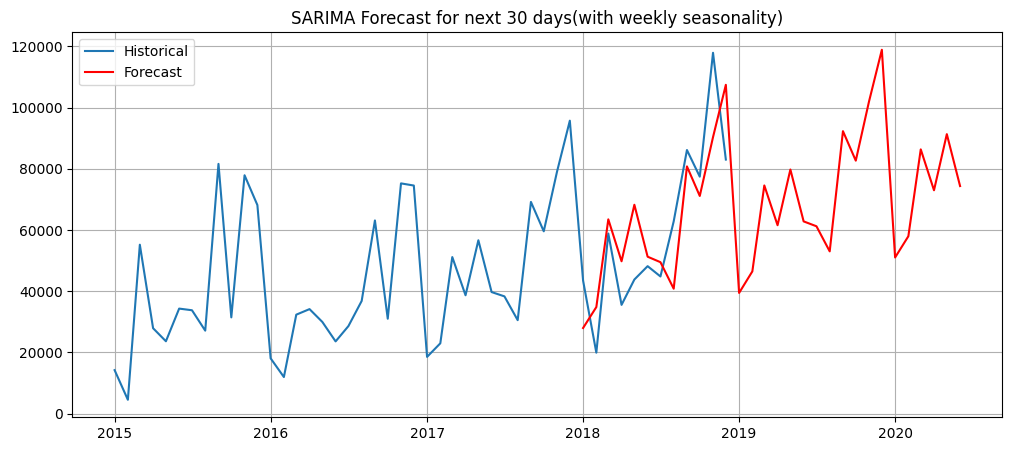

In [107]:
#forecast next 30 dayes
forecast_steps = 30
forecast = model_fit_2.get_forecast(steps=forecast_steps)
forecast_df = forecast.summary_frame()

#plot forecast
plt.figure(figsize=(12,5))
plt.plot(monthly_sales,label='Historical')
plt.plot(forecast_df.index, forecast_df['mean'], label = 'Forecast', color ='red')


plt.legend()
plt.title(f'SARIMA Forecast for next {forecast_steps} days(with weekly seasonality)')
plt.show()
#

In [108]:
import statsmodels.api as sm
#beck testing days
train, test = monthly_sales[:-15], monthly_sales[-15:]

model_bt = sm.tsa.SARIMAX(train,
                       order = (1,1,1),
                       seasonal_order=(1,1,1,12),
                       enforce_stationarity=False,
                       enforce_invertibility=False
                       )
results_bt = model_bt.fit()
pred_bt = results_bt.forecast(steps=15)

In [109]:
#error metrics
mae = mean_absolute_error(test, pred_bt)
mse = mean_squared_error(test, pred_bt)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test - pred_bt) / test)) * 100

print(f"Backtest --> MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")

Backtest --> MAE: 14408.15, MSE: 311492589.12, RMSE: 17649.15, MAPE: 25.41%


- As by two models arima and sarima , byt he MAE, MSE values it shows that the SRIMA modle is better as prediction . because its vlaues are lesser then ARIMA , and lower the mse its prediction are more accurate.

- The dataset contains 9,800 records and 18 variables related to customer orders and sales.
- Initially showed that there were only 11 missing values in the Postal Code column, while the Sales and Order Date columns contained no missing values.
- The date columns were converted into datetime format, and additional features such as year, month, day, and day of the week were extracted.
- The analysis indicated an overall increasing sales trend with noticeable fluctuations across months. Seasonal patterns were also observed, with higher sales generally occurring during the later months of the year, particularly around September to December.
- The dataset was split chronologically, using earlier observations for training and the final 12 months for testing. An ARIMA and SARIMA models was applied for sales forecasting.
- Model evaluation using MAE, RMSE, and R2 showed that the basic ARIMA model had limited predictive performance, with a negative R2 score. This suggests that the model was unable to capture all the variations in the sales data effectively.
- SARIMA models shows the prediction in better then ARIMA , and give R2 score more less, that can be considered as good.

Overall, the analysis confirms the presence of trend and seasonality in the dataset. The seasonality model SRIMA is better fit for prediction.
